# **Nearest Neighbour (NN) comparison between 3D and its 2D projection.** 

**Simplest example of how projection affects NN statistics.**

- Generates N random points within a 3D sphere (radius R).
- Optionally rotates the cloud (Euler angles) before projection.
- Projects to 2D by dropping the z-axis.
- Computes NN in 3D and 2D.
- Compares edge sets and lengths; reports overlap metrics.
- Plots the 3D NN (perspective) and the 2D NN.
- Plots histograms of NN lengths in 3D and 2D.
- Runs for different density profiles (uniform, centrally concentrated, fractal).

Produces the following from Barnes et al. (2026): 

- **Fig 2**: Nearest–neighbour (NN) comparisons for N = 200 points drawn from a uniform spherical distribution within R = 1.0. Top: The NN graph
constructed in 3D, where the blue connections are the 3D NNs (left), its 2D projection where the orange connections are the 2D NNs (middle), and
the corresponding distributions of NN edge lengths (right), highlighting the overall shortening in projection. Bottom: A more detailed breakdown:
the left panel repeats the 2D overlay of 3D and 2D edges, while the right panels show the distributions of ℓ3D, ℓ2D for shared edges, and the ratios
ℓ3D/ℓ2D. Vertical dashed lines mark the medians, and kernel density estimates (KDEs) are overplotted on the histograms. Together these panels
illustrate how projection both compresses lengths and reassigns neighbours, with only the very shortest pairs surviving unchanged.

- **Fig 3 (top row)**: Fig. 3. Nearest-neighbour (NN) comparisons for uniformly sampled point distributions. Top: example realisation with N = 10 points drawn within
a sphere of radius R = 1.0. The NN graph constructed in 3D (left), its 2D projection obtained by dropping the line-of-sight coordinate (middle),
and the corresponding edge-length distributions (right) illustrate how projection systematically shortens apparent separations and modifies the
network connectivity even in a simple, isotropic configuration. [...]

- **Fig 5**. Nearest–neighbour (NN) graphs for a fractal distribution with N = 200 points, fractal dimension D = 1.6, and subdivision ndiv = 3,
within R = 1.0. Each row shows the NN network in 3D (left), the projected NN network in 2D (middle), and the corresponding NN edge–length
distributions (right). The three rows illustrate different viewing geometries: top: no rotation; middle: rotation about the y–axis (β = 90◦); bottom:
rotation about the z–axis (γ = 90◦). Projection systematically shortens the apparent NN separations and rewires connectivity, but the degree of
overlap and compression depends on the line of sight, reflecting the anisotropic, clumpy structure of the fractal distribution.

- **Fig A.1.**: Nearest–neighbour (NN) comparisons for N = 200 points drawn from three centrally concentrated spherical profiles within R = 1.0:
(top) power law with slope p = −2, (middle) truncated Gaussian with σ = 0.25, and (bottom) Plummer with scale radius a = 0.25. Each row
shows the 3D NN graph (left), the 2D projection (centre), and the corresponding distributions of NN edge lengths (right). Projection shortens
apparent separations and rewires most nodes to new, closer neighbours in 2D, with mean ratios ℓ3D/ℓ2D ∼ 2.3–2.4, well above the geometric
baseline 4/π ≃ 1.27.

In [1]:
# Core scientific imports
import numpy as np
import matplotlib.pyplot as plt

# corespaceing3d imports
from corespaceing3d import main
from corespaceing3d.plotting import plot_3d, plot_2d, plot_overlay_2d, plot_length_histograms, plot_length_histograms_shared_forced


In [2]:
# ------------------------- configuration -------------------------
N_POINTS = 200       # number of cores
RADIUS = 1.0         # sphere radius
SEED = 42            # RNG seed for reproducibility

# Rotation of the 3D clump *before* projecting to 2D
# (Right-handed, extrinsic rotations; order Z (alpha), Y (beta), X (gamma))
ALPHA_DEG = 0     # rotate about Z
BETA_DEG  = 0     # rotate about Y
GAMMA_DEG = 0     # rotate about X

# Toggle plotting
SHOW_PLOTS = True
# -----------------------------------------------------------------


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  uniform (Uniform)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 30 / 199
Only in 3D:  109
Only in 2D:  107
Overlap (3D→2D recovery): 0.216
Jaccard similarity:        0.122

Total NN length
------------------------------------------------------------------------
3D: 24.42287
2D: 9.48117

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.394  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=139):
  mean=0.17570, median=0.17903, std=0.06186, mad=0.04557
  min=0.04724, p10=0.09221, p25=0.12570, p50=0.17903, p75=0.21993, p90=0.24927, p95=0.27941, p99=0.30817, max=0.32680

2D NN edge-length stats (N=137):
  mean=0.06921, median=0.06274, std=0.03918, mad=0.02422
  min=0.00312, p10=0.02683, p25=0.04264, p50=0.06274, p75=0.08940, p90=0.11403, p95=0

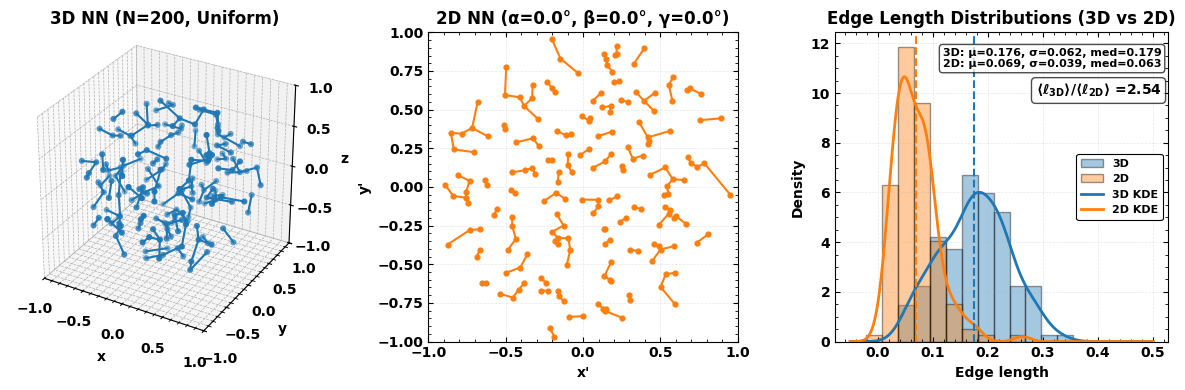

In [3]:
# Run the pipeline
profile = "uniform"

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.png",
    dpi=300, bbox_inches="tight"
)

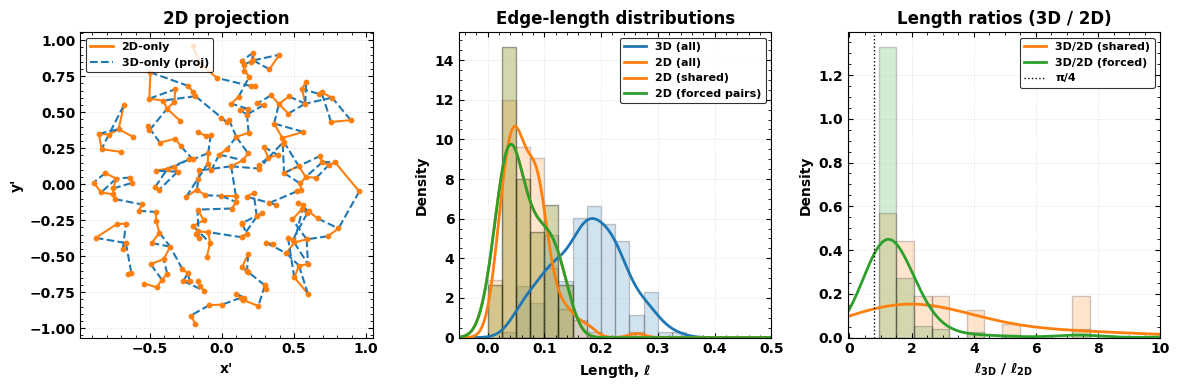

In [4]:
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 4))

bins_len=np.linspace(-0.1, 0.5, 25)
bins_rat=np.linspace(-0.75, 10, 20)

ax0 = plot_overlay_2d(ax0, pts2d, out, title="2D projection")
ax1, ax2 = plot_length_histograms_shared_forced(ax1, ax2, out, len3, len2, kde=True, bins_len=bins_len, bins_rat=bins_rat)

ax1.set_xlim(-0.05, 0.5)
ax2.set_xlim(-0.05, 10)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_lengths_ratios_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)


NN comparison: 3D vs projected 2D
Sampling: N=10, R=1
Profile:  uniform (Uniform)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 4 / 9
Only in 3D:  3
Only in 2D:  4
Overlap (3D→2D recovery): 0.571
Jaccard similarity:        0.364

Total NN length
------------------------------------------------------------------------
3D: 3.79650
2D: 2.65473

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.612  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=7):
  mean=0.54236, median=0.57699, std=0.19778, mad=0.09796
  min=0.22219, p10=0.33208, p25=0.44219, p50=0.57699, p75=0.63447, p90=0.72515, p95=0.78457, p99=0.83211, max=0.84400

2D NN edge-length stats (N=8):
  mean=0.33184, median=0.38094, std=0.11359, mad=0.05376
  min=0.14478, p10=0.18867, p25=0.24322, p50=0.38094, p75=0.41821, p90=0.43070, p95=0.43771, p99=0

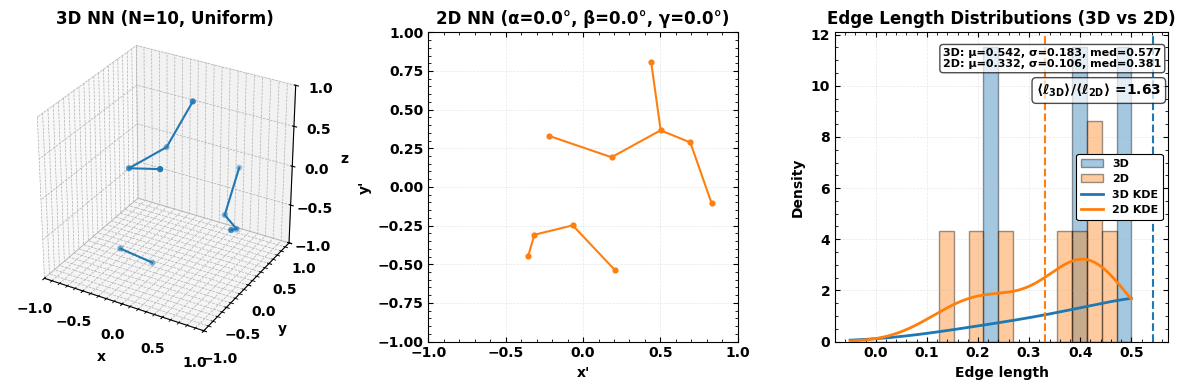

In [5]:
# Run the pipeline
profile = "uniform"
n_points = 10

out = main(
    N_POINTS=n_points,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{n_points}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  gaussian (Gaussian, σ=0.25)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 30 / 199
Only in 3D:  114
Only in 2D:  111
Overlap (3D→2D recovery): 0.208
Jaccard similarity:        0.118

Total NN length
------------------------------------------------------------------------
3D: 15.59189
2D: 6.28298

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.412  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=144):
  mean=0.10828, median=0.09736, std=0.06929, mad=0.03299
  min=0.01568, p10=0.04220, p25=0.06651, p50=0.09736, p75=0.13293, p90=0.17652, p95=0.21838, p99=0.39371, max=0.46767

2D NN edge-length stats (N=141):
  mean=0.04456, median=0.03056, std=0.05142, mad=0.01095
  min=0.00082, p10=0.01222, p25=0.02071, p50=0.03056, p75=0.04758, p90=0.08

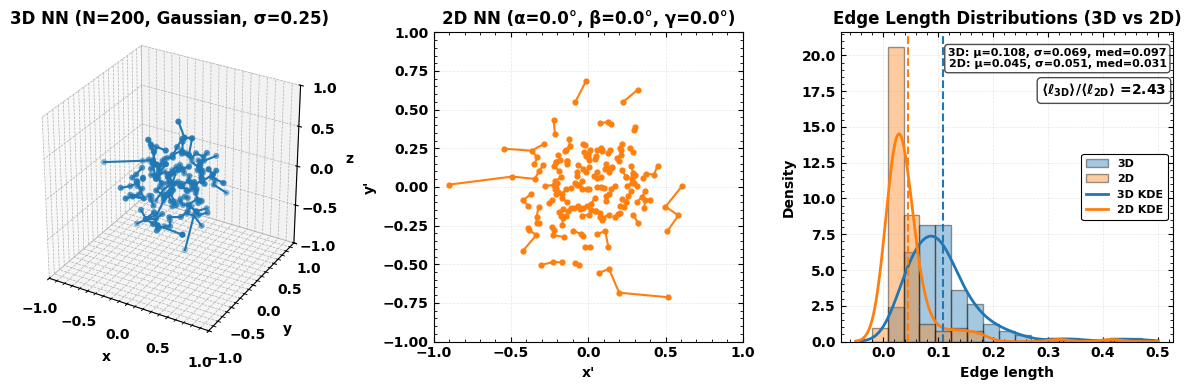

In [6]:
# Run the pipeline
profile = "gaussian"
sigma = 0.25

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    profile_kwargs={"sigma": sigma},      # supply the right params for the chosen profile
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_s{sigma}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  powerlaw (Power-law, p=-2)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 30 / 199
Only in 3D:  111
Only in 2D:  107
Overlap (3D→2D recovery): 0.213
Jaccard similarity:        0.121

Total NN length
------------------------------------------------------------------------
3D: 21.61585
2D: 8.78938

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.418  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=141):
  mean=0.15330, median=0.14334, std=0.08968, mad=0.06258
  min=0.00599, p10=0.04819, p25=0.08267, p50=0.14334, p75=0.20863, p90=0.27506, p95=0.32077, p99=0.36705, max=0.42567

2D NN edge-length stats (N=137):
  mean=0.06416, median=0.05013, std=0.05636, mad=0.02564
  min=0.00201, p10=0.01500, p25=0.02672, p50=0.05013, p75=0.07788, p90=0.128

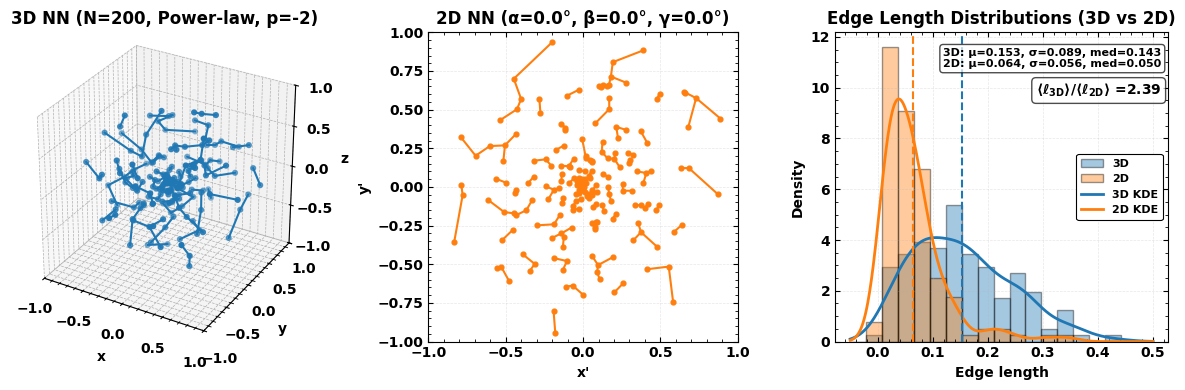

In [7]:
# Run the pipeline
profile = "powerlaw"
p = -2.0

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    profile_kwargs={"p": p},         # supply the right params for the chosen profile
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  plummer (Plummer, a=0.25)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 29 / 199
Only in 3D:  114
Only in 2D:  106
Overlap (3D→2D recovery): 0.203
Jaccard similarity:        0.116

Total NN length
------------------------------------------------------------------------
3D: 16.28935
2D: 6.73452

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.438  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=143):
  mean=0.11391, median=0.08357, std=0.08402, mad=0.03263
  min=0.02119, p10=0.04443, p25=0.05841, p50=0.08357, p75=0.14331, p90=0.21102, p95=0.27834, p99=0.43150, max=0.49224

2D NN edge-length stats (N=135):
  mean=0.04989, median=0.03260, std=0.05700, mad=0.01522
  min=0.00248, p10=0.01202, p25=0.02088, p50=0.03260, p75=0.05467, p90=0.0927

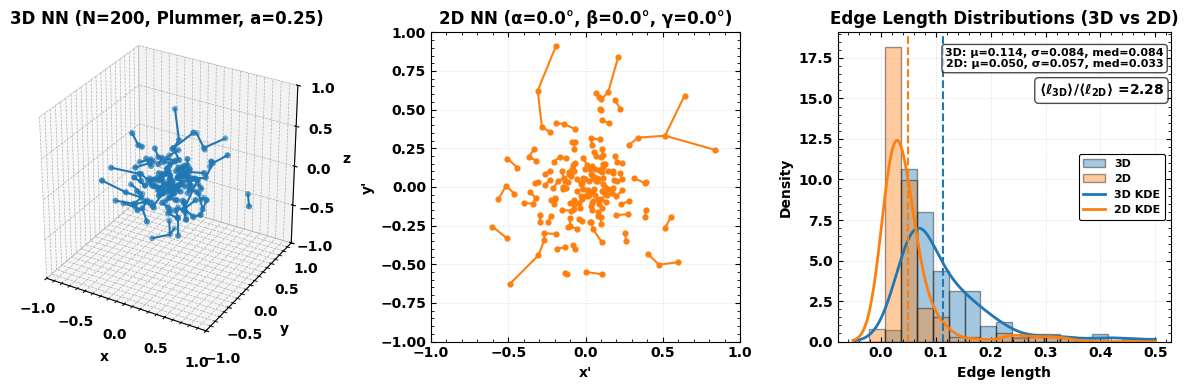

In [8]:
# Run the pipeline
profile = "plummer"
a = 0.25

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,                 # or 'uniform','powerlaw','exponential','plummer','shell'
    profile_kwargs={"a": a},         # supply the right params for the chosen profile
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  fractal_cw (Fractal, D=2.5, n$_\mathrm{div}$=2)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 36 / 199
Only in 3D:  106
Only in 2D:  100
Overlap (3D→2D recovery): 0.254
Jaccard similarity:        0.149

Total NN length
------------------------------------------------------------------------
3D: 14.88611
2D: 5.91120

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.415  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=142):
  mean=0.10483, median=0.09882, std=0.04228, mad=0.02679
  min=0.01675, p10=0.05682, p25=0.07588, p50=0.09882, p75=0.12847, p90=0.16130, p95=0.18257, p99=0.21664, max=0.22964

2D NN edge-length stats (N=136):
  mean=0.04346, median=0.03920, std=0.02814, mad=0.01593
  min=0.00216, p10=0.01419, p25=0.02308, p50=0.03920, p

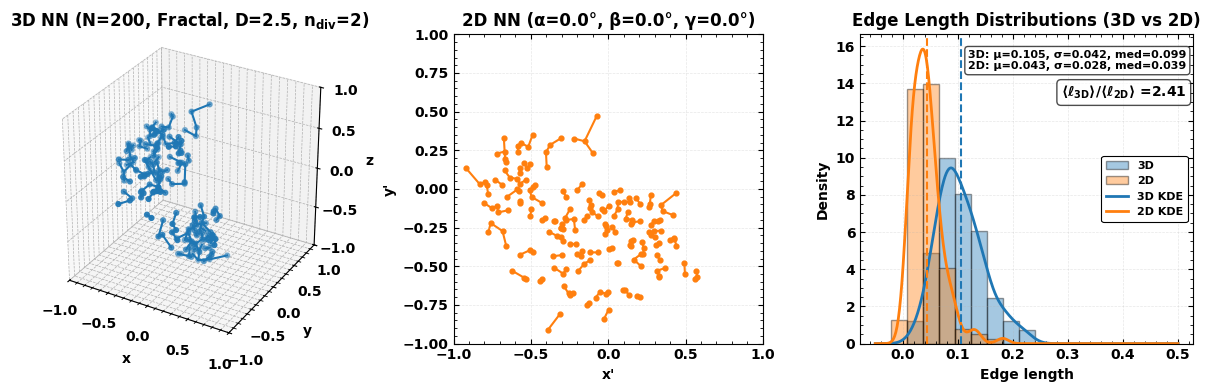

In [9]:
# Run the pipeline (FRACTAL)
profile = "fractal_cw"

# D = 2.1         # fractal dimension (0 < D <= 3), e.g. 1.6–2.6 for clumpy clusters
# n_div = 3      # subdivisions per axis per generation (typically 2)
D = 2.5         # fractal dimension (0 < D <= 3), e.g. 1.6–2.6 for clumpy clusters
n_div = 2      # subdivisions per axis per generation (typically 2)

jitter = True  # add small Gaussian jitter to break grid regularity
prune = True   # prune to sphere before scaling (approx. spherical cluster)

out = main(
    N_POINTS=N_POINTS,
    RADIUS=RADIUS,
    SEED=SEED,
    profile=profile,  # 'uniform'|'powerlaw'|'exponential'|'plummer'|'shell'|'fractal'
    profile_kwargs={"D": D, "n_div": n_div, "jitter": jitter, "prune_to_sphere": prune},
    ALPHA_DEG=ALPHA_DEG,
    BETA_DEG=BETA_DEG,
    GAMMA_DEG=GAMMA_DEG,
    verbose=True,
)

# Unpack for plotting
pts3d_rot = out["pts3d_rot"]
pts2d     = out["pts2d"]
edges3d   = out["edges3d"]
edges2d   = out["edges2d"]
len3      = out["len3"]
len2      = out["len2"]
title3d   = out["titles"]["title3d"]
title2d   = out["titles"]["title2d"]

# 3-panel figure
fig = plt.figure(figsize=(12, 4))
ax3d   = fig.add_subplot(131, projection='3d')
ax2d   = fig.add_subplot(132)
axhist = fig.add_subplot(133)

plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
plot_2d(ax2d, pts2d, edges2d, title=title2d)
bins = np.linspace(-0.05, 0.5, 20)
plot_length_histograms(axhist, len3, len2, bins=bins)

fig.tight_layout()

fig.savefig(
    "./../figures/"
    f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
    f"_D{D:.2f}_ndiv{n_div}_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
    dpi=300, bbox_inches="tight"
)


NN comparison: 3D vs projected 2D
Sampling: N=200, R=1
Profile:  fractal_cw (Fractal, D=1.6, n$_\mathrm{div}$=3)
Rotation: α=0.0°, β=0.0°, γ=0.0° (extrinsic Z-Y-X)

Edge-set overlap
------------------------------------------------------------------------
Shared edges: 69 / 199
Only in 3D:  67
Only in 2D:  68
Overlap (3D→2D recovery): 0.507
Jaccard similarity:        0.338

Total NN length
------------------------------------------------------------------------
3D: 5.97550
2D: 3.45526

Mean edge-length ratio
------------------------------------------------------------------------
<l_2D>/<l_3D> = 0.574  (geometric expectation ≈ 0.785)

3D NN edge-length stats (N=136):
  mean=0.04394, median=0.03803, std=0.02369, mad=0.01364
  min=0.00657, p10=0.02021, p25=0.02601, p50=0.03803, p75=0.05602, p90=0.07465, p95=0.08796, p99=0.11799, max=0.14632

2D NN edge-length stats (N=137):
  mean=0.02522, median=0.01831, std=0.02023, mad=0.00748
  min=0.00406, p10=0.00847, p25=0.01262, p50=0.01831, p75=

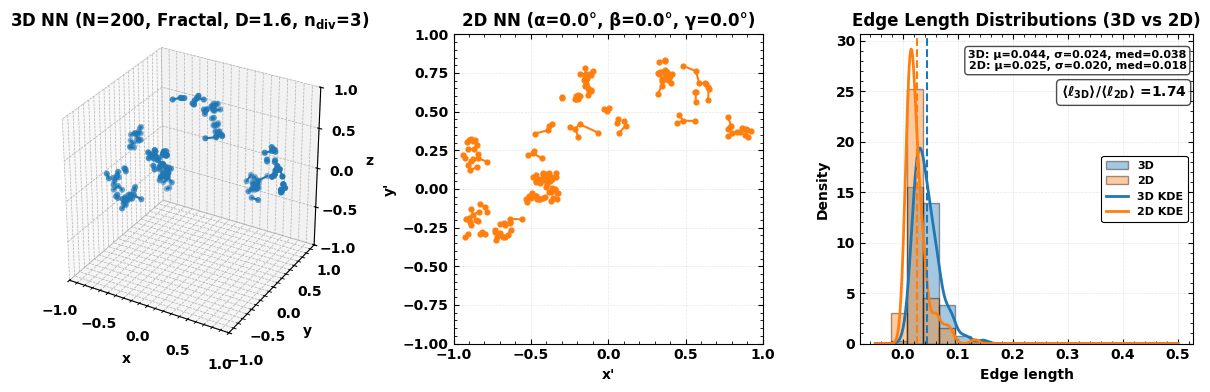

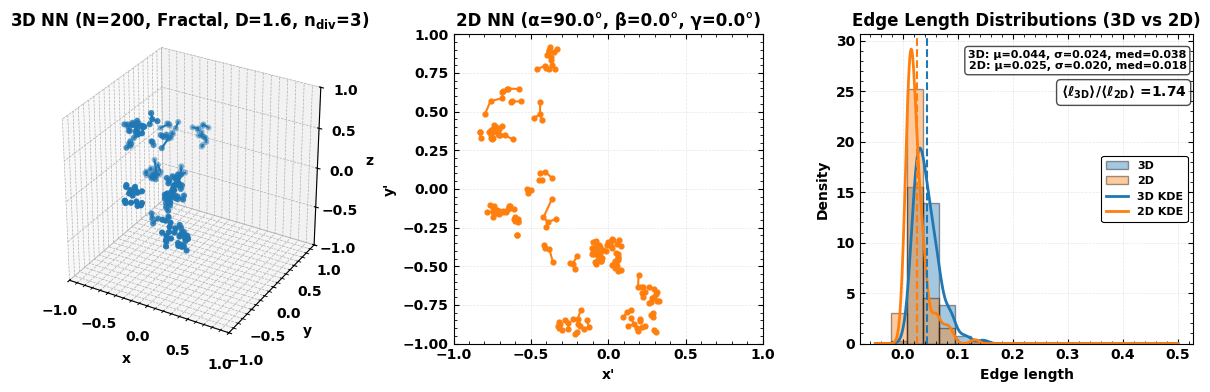

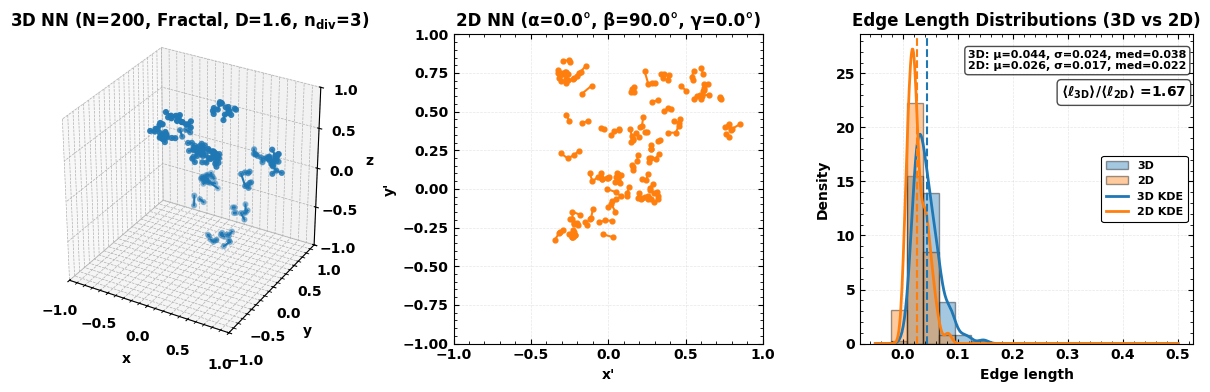

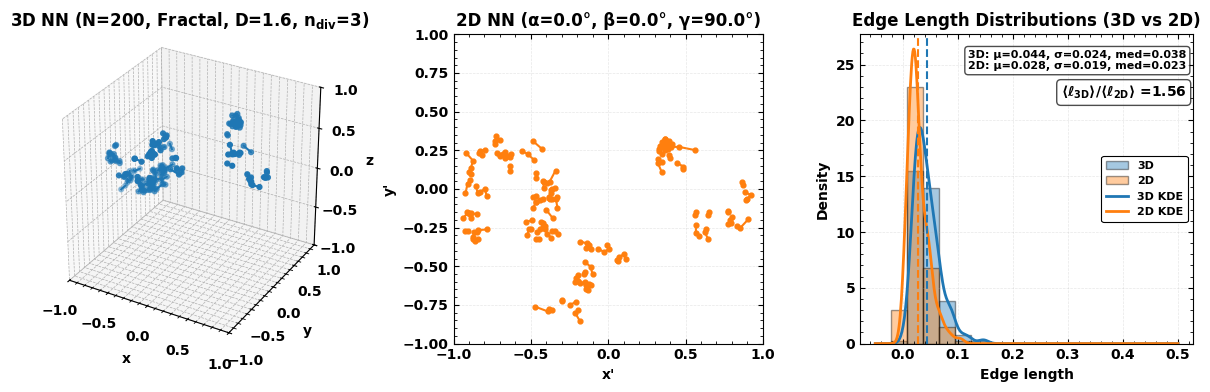

In [10]:
alpha_degs = [0, 90, 0, 0]     # rotate about Z
beta_degs  = [0, 0, 90, 0]     # rotate about Y
gamma_degs = [0, 0, 0, 90]     # rotate about X

for ALPHA_DEG, BETA_DEG, GAMMA_DEG in zip(alpha_degs, beta_degs, gamma_degs):

    # Run the pipeline (FRACTAL)
    profile = "fractal_cw"
    D = 1.6         # fractal dimension (0 < D <= 3), e.g. 1.6–2.6 for clumpy clusters
    n_div = 3      # subdivisions per axis per generation (typically 2)
    jitter = True  # add small Gaussian jitter to break grid regularity
    prune = True   # prune to sphere before scaling (approx. spherical cluster)

    out = main(
        N_POINTS=N_POINTS,
        # N_POINTS=100,
        RADIUS=RADIUS,
        SEED=SEED,
        profile=profile,  # 'uniform'|'powerlaw'|'exponential'|'plummer'|'shell'|'fractal'
        profile_kwargs={"D": D, "n_div": n_div, "jitter": jitter, "prune_to_sphere": prune},
        ALPHA_DEG=ALPHA_DEG,
        BETA_DEG=BETA_DEG,
        GAMMA_DEG=GAMMA_DEG,
        verbose=True,
    )

    # Unpack for plotting
    pts3d_rot = out["pts3d_rot"]
    pts2d     = out["pts2d"]
    edges3d   = out["edges3d"]
    edges2d   = out["edges2d"]
    len3      = out["len3"]
    len2      = out["len2"]
    title3d   = out["titles"]["title3d"]
    title2d   = out["titles"]["title2d"]

    # 3-panel figure
    fig = plt.figure(figsize=(12, 4))
    ax3d   = fig.add_subplot(131, projection='3d')
    ax2d   = fig.add_subplot(132)
    axhist = fig.add_subplot(133)

    plot_3d(ax3d, pts3d_rot, edges3d, title=title3d)
    plot_2d(ax2d, pts2d, edges2d, title=title2d)
    bins = np.linspace(-0.05, 0.5, 20)
    plot_length_histograms(axhist, len3, len2, bins=bins)

    fig.tight_layout()

    fig.savefig(
        "./../figures/"
        f"nn_{profile}_N{N_POINTS}_R{RADIUS}"
        f"_D{D:.2f}_ndiv{n_div}_a{ALPHA_DEG:.0f}_b{BETA_DEG:.0f}_g{GAMMA_DEG:.0f}.pdf",
        dpi=300, bbox_inches="tight"
    )